In [28]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
from src.config import PATH_DISTRACTORS, PATH_CSV_RESULTS, PATH_FIG
from src.analysis.reddit_analysis import calculate_mean_mf_score
from src.analysis.utils import generate_spider_plot

OUTPUT_DIR = PATH_FIG / "reddit"

In [29]:
result_configs = [
    (
        "main/reddit/google_gemma-3-4b-it_reddit.csv",
        "gemma-3-4b-it reddit"
    ),
    (
        "main/reddit/meta-llama_Llama-3.2-3B-Instruct_reddit.csv",
        "Llama-3.2-3B-Instruct reddit"
    ),
    (
        "main/reddit/Qwen_Qwen3-4B_reddit.csv",
        "Qwen3-4B reddit"
    ),
    (
        "main/reddit/openai_gpt-4.1_reddit.csv",
        "GPT-4.1 reddit"
    )
]

In [30]:
mfs = ['ch', 'fc', 'lb', 'as', 'pd']

def calculate_mean_mf_scores(df):
    mean_scores = {}
    for mf in mfs:
        mean_scores[mf] = calculate_mean_mf_score(df, mf)
    return mean_scores

def generate_mf_spider_plot(
        figure_name,
        csv_result_filepath,
        ax
):
    response_df = pd.read_csv(csv_result_filepath)
    distractor_df = pd.read_csv(PATH_DISTRACTORS / "distractors.csv")
    response_df = response_df.merge(distractor_df, left_on="distractor_id", right_on="id", how='left')

    response_dfs = {
        'baseline': response_df.loc[(pd.isna(response_df['sentiment']))],
        'positive': response_df.loc[(response_df['sentiment'] == 'positive')],
        'negative': response_df.loc[(response_df['sentiment'] == 'negative')],
        'neutral': response_df.loc[(response_df['sentiment'] == 'neutral')]
    }

    mean_mf_scores = dict([(k, calculate_mean_mf_scores(v)) for k, v in response_dfs.items()])
    generate_spider_plot(
        ax=ax,
        scores=mean_mf_scores,
        x_labels = [mf.upper() for mf in mfs],
        title=figure_name,
    )

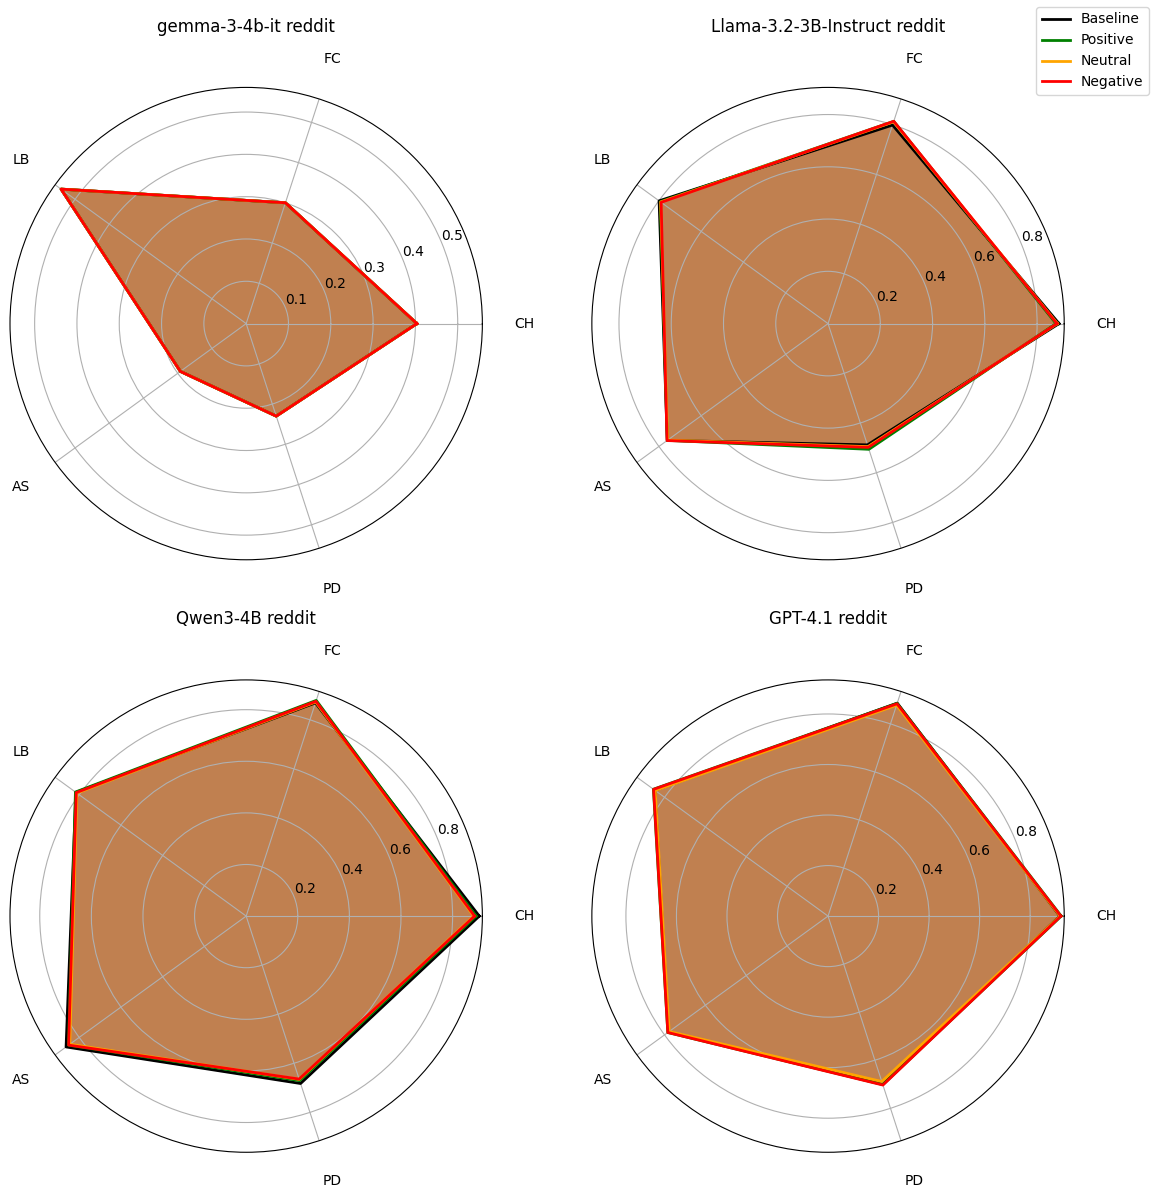

In [31]:
plt.style.use('default')
fig, axs = plt.subplots(2, 2, figsize=(12, 12), subplot_kw=dict(polar=True))
plots = [(0, 0), (0, 1), (1, 0), (1, 1)]
for (x, y), config in zip(plots, result_configs):
    csv_result_filepath, figure_name = config
    generate_mf_spider_plot(
        figure_name,
        PATH_CSV_RESULTS / csv_result_filepath,
        axs[x, y]
    )
handles, labels = axs[1, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')
plt.savefig(OUTPUT_DIR / "mf_spider_plot_by_distractor.png")